# Placebo-in-time and falsification: a UK CO₂ case study

## What does it mean to "find an effect"?

When a model reports an effect whose credible interval excludes zero, most analysts exhale.  The intervention worked.  Ship the slide deck.

But excluding zero is a statement about **parameter uncertainty** --- the noise *inside* the model.  It tells you that, *conditional on the model being correct*, the data are unlikely to have been generated by a zero effect.  That conditional clause does most of the heavy lifting, and it is almost never true.

Every quasi-experimental method rests on identifying assumptions: parallel trends, no anticipation, no interference. When those assumptions crack, and they always crack a little, the model's counterfactual drifts from truth.  [Bugaev & Trujillo (2026)](https://github.com/cetagostini/placebo-in-time-quasi-experiment/blob/main/pdf/paper.pdf) call this gap the **structural error**: the systematic deviation between what the model promises and what reality delivers. Standard credible intervals are blind to it.

Gallea puts the epistemological point sharply:

> *"We cannot prove causality with a simple test [...] the most important assumption, called the unconfoundedness assumption, is usually not testable.  We can only assess how plausible the assumption is."*  --- Gallea (2026)

So we cannot *prove* that a policy worked.  What we can do is behave like **causal detectives**, accumulate evidence from multiple angles, stress-test our estimator, and ask whether the story holds together. Each piece of evidence is small. The argument is the pile.

This notebook demonstrates the full detective workflow on a real policy question, using [CausalPy](https://causalpy.readthedocs.io).

In particular, this notebook showcases the **placebo-in-time** check: a way to stress-test the identifying assumptions of an ITS model by re-fitting it on pre-intervention dates where we *know* nothing happened. The spread of those false-positive 'effects' becomes a calibrated null distribution. The actual post-intervention effect only counts as evidence if it lives clearly outside that null. Used together with falsification on related outcomes, this is how you move from "the credible interval excludes zero" to a causal claim you can defend to yourself, to a colleague, and to a skeptical stakeholder.

## The case: the UK's 2013 Carbon Price Floor

In April 2013, the UK introduced the **Carbon Price Floor (CPF)**, a top-up tax on carbon emissions from electricity generation.  The EU's Emissions Trading System was supposed to make dirty power expensive, but the carbon price had collapsed to around EUR 5/tonne. The CPF set a floor well above that, deliberately designed to make coal power unprofitable relative to gas and renewables.

**The causal question:** Did the Carbon Price Floor reduce coal CO₂ ~ emissions in the UK?

We will answer this in four steps, each one small and honest:

| Step | Question | What we learn |
|:-----|:---------|:--------------|
| **1. Estimate** | Did coal CO₂ drop after 2013? | The size and direction of the change |
| **2. Calibrate** | How often does this model produce false positives? | Whether we should trust the estimator at all |
| **3. Trace the mechanism** | If coal died, where did the energy go? | Whether the substitution story is consistent |
| **4. Check the boundary** | Did total CO₂ or energy demand change? | Whether something *else* explains the result |

No single step is conclusive.  Together, they build a case.

## Setup

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import causalpy as cp

%config InlineBackend.figure_format = 'retina'
warnings.filterwarnings("ignore")

/opt/anaconda3/envs/CausalPy/lib/python3.13/site-packages/pymc_extras/model/marginal/graph_analysis.py:10: FutureWarning: `pytensor.graph.basic.io_toposort` was moved to `pytensor.graph.traversal.io_toposort`. Calling it from the old location will fail in a future release.
  from pytensor.graph.basic import io_toposort


## The data

We combine two open datasets from **Our World in Data**: annual CO₂ emissions and energy generation by source.  We focus on the UK from 1990 to 2018 --- 23 years before the policy and 5 after.

In [2]:
# NOTE: This notebook fetches data at runtime from Our World in Data's
# public S3 buckets (nyc3.digitaloceanspaces.com). If those URLs change
# or become unreachable the cell below will fail; mirror the CSVs
# locally and point CO2_URL / ENERGY_URL at them if that happens.
CO2_URL = "https://nyc3.digitaloceanspaces.com/owid-public/data/co2/owid-co2-data.csv"
ENERGY_URL = (
    "https://nyc3.digitaloceanspaces.com/owid-public/data/energy/owid-energy-data.csv"
)

MIN_YEAR = 1990
MAX_YEAR = 2018

# --- CO2 data ---
df_co2 = pd.read_csv(CO2_URL)
df_co2 = df_co2[
    (df_co2["country"] == "United Kingdom")
    & (df_co2["year"] >= MIN_YEAR)
    & (df_co2["year"] <= MAX_YEAR)
].copy()

# --- Energy data ---
df_energy = pd.read_csv(ENERGY_URL)
df_energy = df_energy[
    (df_energy["country"] == "United Kingdom")
    & (df_energy["year"] >= MIN_YEAR)
    & (df_energy["year"] <= MAX_YEAR)
][["year", "coal_electricity"]].copy()

# Merge on year
df_uk = df_co2.merge(df_energy, on="year", how="left")

# ITS needs a DatetimeIndex
df_uk["date"] = pd.to_datetime(df_uk["year"], format="%Y")
df_uk = df_uk.set_index("date").sort_index()

treatment_time = pd.to_datetime("2013-01-01")

print(f"UK observations: {len(df_uk)}")
print(f"Years: {df_uk['year'].min()} – {df_uk['year'].max()}")
print(f"Treatment: {treatment_time.year}")
print(f"Pre-treatment: {len(df_uk.loc[: treatment_time - pd.Timedelta(days=1)])} years")
print(f"Post-treatment: {len(df_uk.loc[treatment_time:])} years")
df_uk[["year", "co2", "coal_co2", "coal_electricity", "energy_per_gdp"]].head(10)

UK observations: 29
Years: 1990 – 2018
Treatment: 2013
Pre-treatment: 23 years
Post-treatment: 6 years


,year,co2,coal_co2,coal_electricity,energy_per_gdp
date,,,,,
1990-01-01,1990,601.945,252.690,206.44,1.666
1991-01-01,1991,609.413,253.623,211.46,1.721
1992-01-01,1992,593.846,237.747,193.64,1.706
1993-01-01,1993,579.613,207.686,171.25,1.686
1994-01-01,1994,574.017,195.376,161.34,1.605
1995-01-01,1995,566.159,181.699,155.21,1.572
1996-01-01,1996,586.761,173.072,147.27,1.609
1997-01-01,1997,562.708,154.729,121.97,1.535
1998-01-01,1998,568.544,154.088,122.97,1.501


## Looking at the data

Before fitting anything, look.  Patterns you can see with your eyes are more robust than patterns that require a model to reveal.

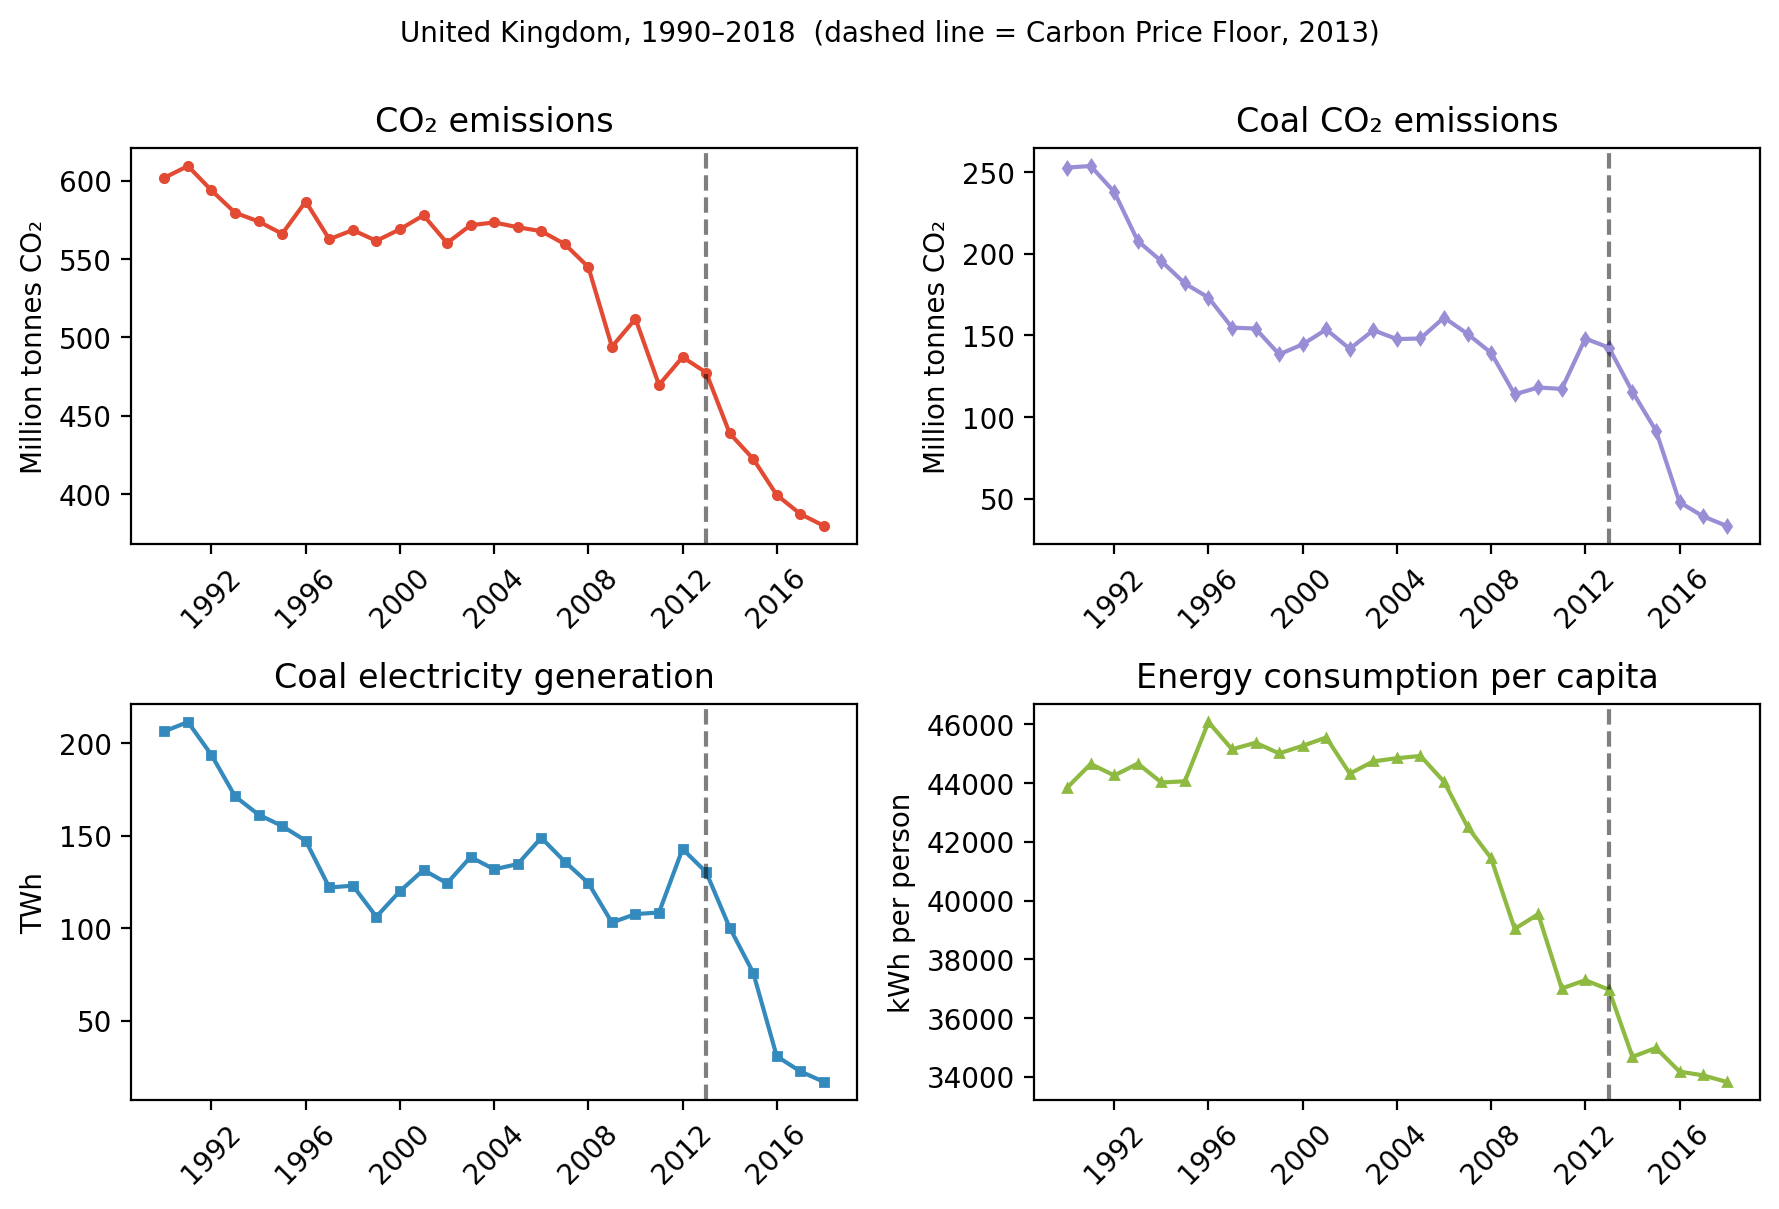

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6))

# CO2
ax = axes[0, 0]
ax.plot(df_uk.index, df_uk["co2"], "o-", color="#E24A33", lw=1.5, ms=3)
ax.axvline(treatment_time, ls="--", color="k", alpha=0.5)
ax.set_ylabel("Million tonnes CO₂")
ax.set_title("CO₂ emissions")

# Coal CO2
ax = axes[0, 1]
ax.plot(df_uk.index, df_uk["coal_co2"], "d-", color="#988ED5", lw=1.5, ms=3)
ax.axvline(treatment_time, ls="--", color="k", alpha=0.5)
ax.set_ylabel("Million tonnes CO₂")
ax.set_title("Coal CO₂ emissions")

# Coal electricity
ax = axes[1, 0]
ax.plot(df_uk.index, df_uk["coal_electricity"], "s-", color="#348ABD", lw=1.5, ms=3)
ax.axvline(treatment_time, ls="--", color="k", alpha=0.5)
ax.set_ylabel("TWh")
ax.set_title("Coal electricity generation")

# Energy per capita
ax = axes[1, 1]
ax.plot(df_uk.index, df_uk["energy_per_capita"], "^-", color="#8EBA42", lw=1.5, ms=3)
ax.axvline(treatment_time, ls="--", color="k", alpha=0.5)
ax.set_ylabel("kWh per person")
ax.set_title("Energy consumption per capita")

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=45)

fig.suptitle(
    "United Kingdom, 1990–2018  (dashed line = Carbon Price Floor, 2013)",
    fontsize=10,
    y=1.00,
)
fig.tight_layout()
plt.show()

Four series, one dashed line. Coal CO₂ ~ and coal electricity show a visible break after 2013. Total CO₂ declines more gently. Energy per capita drifts down throughout, with no obvious discontinuity.

These are eyeball impressions. Now, we need a model.

## Question 1: Estimate the effect on coal CO₂

### Why coal CO₂?

The Carbon Price Floor was a tax on **electricity generation from fossil fuels**.  Its direct, first-order target was coal. If we want the sharpest test of whether the policy worked, we should measure the outcome closest to the mechanism: **coal CO₂ emissions**.

Total CO₂ is tempting because it is the ultimate goal, but it mixes the policy's direct effect with dozens of other forces (transport, industry, heating).  Starting with the sharpest outcome gives us the strongest signal-to-noise ratio.

### The model

We use CausalPy's `BayesianBasisExpansionTimeSeries`, a flexible Bayesian model that captures nonlinear trends via basis functions and changepoints. It fits the pre-treatment data and projects forward; the gap between projection and reality is the estimated effect.

In [4]:
sampler_kwargs = {
    "target_accept": 0.89,
    "step_scale": 0.45,
    "max_treedepth": 100,
    "chains": 8,
    "draws": 500,
    "cores": 16,
}


def its_model():
    """Fresh BayesianBasisExpansionTimeSeries model (single-use)."""
    return cp.pymc_models.BayesianBasisExpansionTimeSeries(
        n_order=4,
        n_changepoints_trend=8,
        prior_sigma=0.05,
        sample_kwargs=sampler_kwargs,
    )

In [5]:
result_coal_co2 = cp.InterruptedTimeSeries(
    data=df_uk[["coal_co2"]],
    treatment_time=treatment_time,
    formula="coal_co2 ~ 1",
    model=its_model(),
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (8 chains in 8 jobs)
NUTS: [fourier_beta, delta, beta, sigma]


Output()

Sampling 8 chains for 1_000 tune and 500 draw iterations (8_000 + 4_000 draws total) took 46 seconds.
Sampling: [beta, delta, fourier_beta, sigma, y_hat]
Sampling: [y_hat]


Output()

Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]


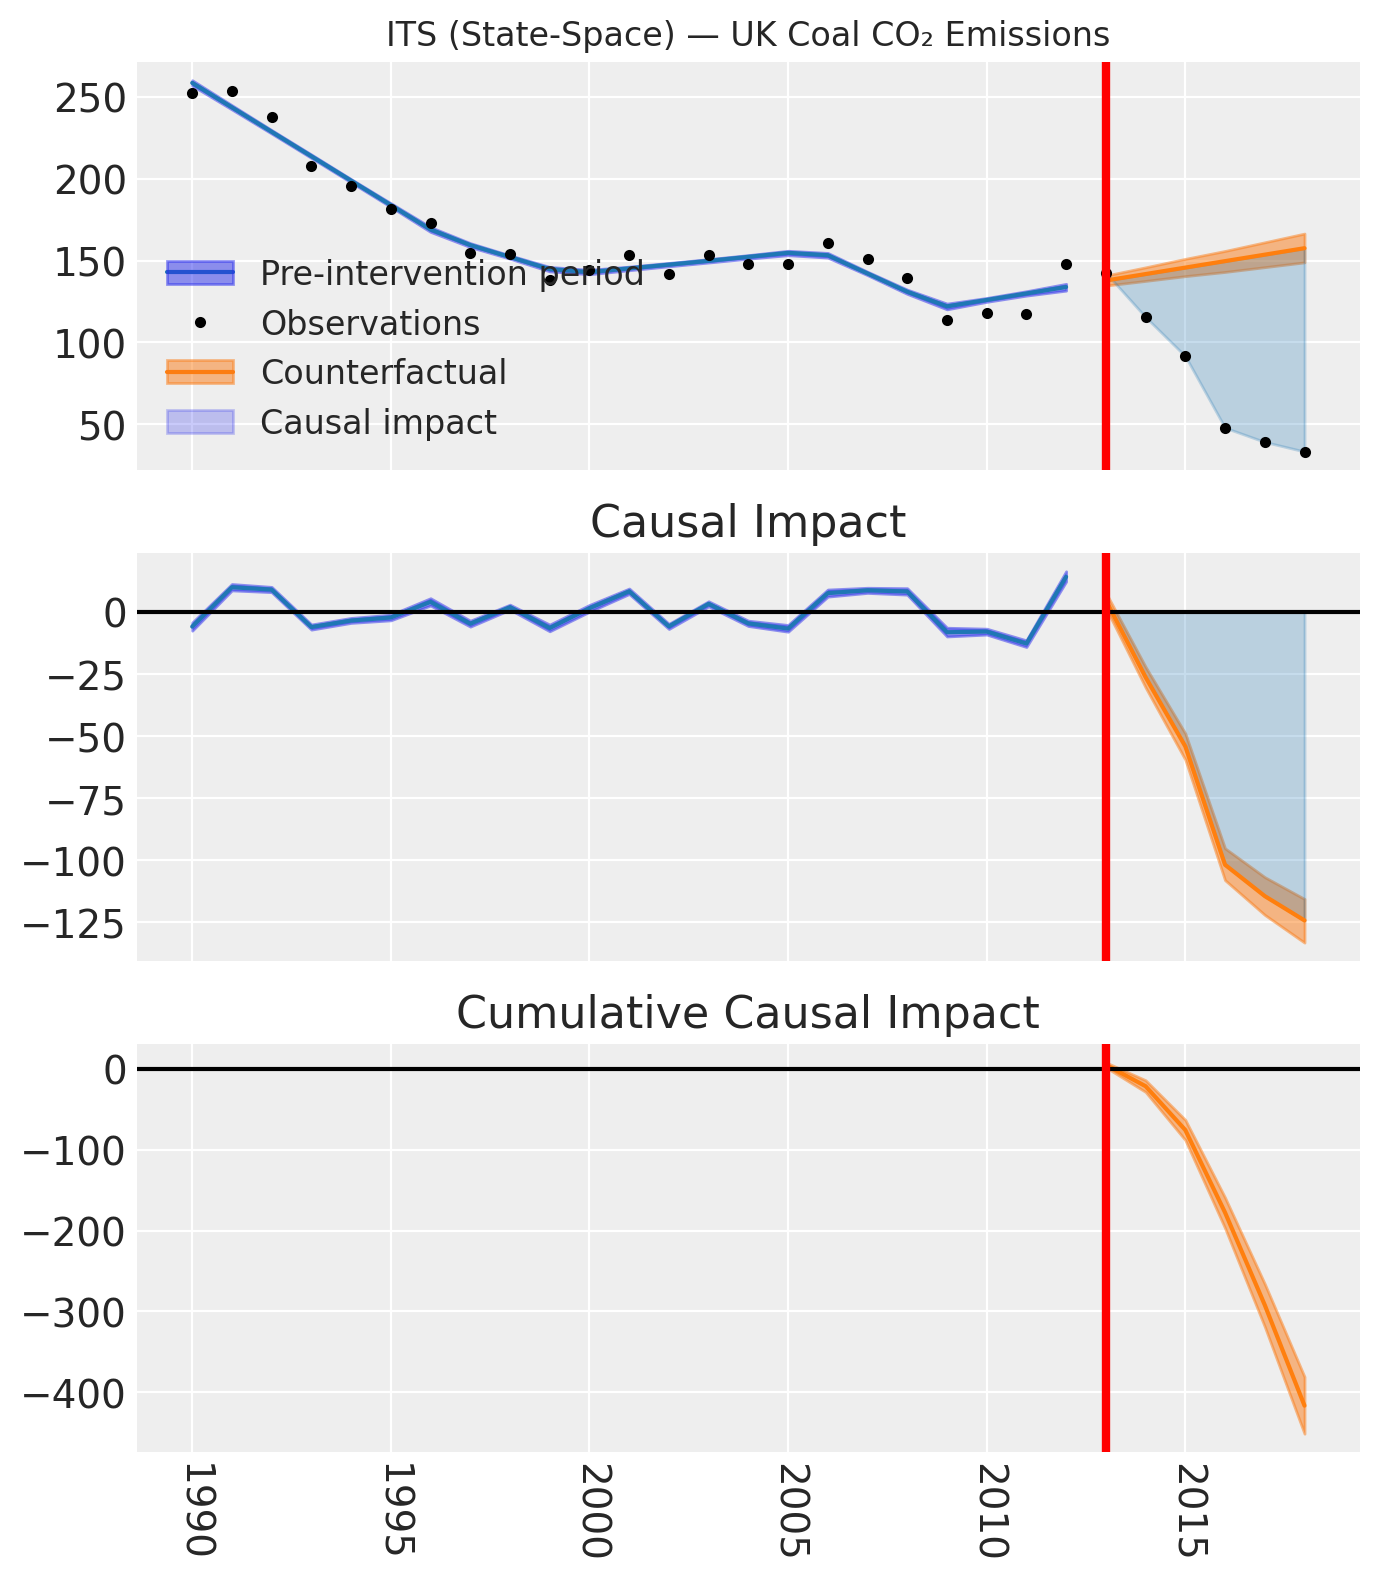

In [6]:
fig, axes = result_coal_co2.plot(show=False)
axes[0].set_title("ITS (State-Space) — UK Coal CO₂ Emissions")
plt.tight_layout()
plt.show()

The model reports a large negative effect. Coal CO₂ fell far below what the pre-treatment trend would predict. The credible interval excludes zero comfortably.

**But recall our opening point.**  An interval that excludes zero tells us about parameter noise, not about whether the model's assumptions hold. Before we celebrate, we need to ask: *how often does this estimator produce false positives of this size when nothing happened?*

## Question 2: How often does the model lie?

### The structural error problem

Standard Bayesian credible intervals capture two kinds of uncertainty:

- **Aleatoric**: irreducible noise in the data.
- **Epistemic (parameter)**: uncertainty about model parameters that
  shrinks with more data.

But there is a third kind: **structural uncertainty**. When the model's identifying assumptions are violated, and they always are, at least a little. The counterfactual prediction drifts from truth. The model doesn't know it is wrong. It reports a tight interval around a biased estimate.

### Placebo-in-Time: calibrating the thermometer

The idea is simple. Before you use the model on the real treatment date, run it on **periods where you know nothing happened**:

1. **Shift** the treatment date backward into the pre-treatment period.
2. **Re-fit** the model at the fake date.
3. **Repeat** for several placebo windows.
4. **Pool** the results into a hierarchical null model.

Each placebo fit asks: "How big an 'effect' does the model find when the true effect is zero?"  The distribution of those false alarms is the **null predictive distribution**, what structural noise looks like for this estimator on this data.

The real effect is meaningful only if it is clearly outside this distribution. Not outside zero, instead outside the range of normal model failures.

### Running the calibration with CausalPy

CausalPy's `Pipeline` composes the estimation and the sensitivity check into a single reproducible call.

A few words on the `PlaceboInTime` settings we pass below:

- `n_folds=3` says we want three placebo intervention dates inside the pre-period --- each fold asks "what would the model have reported if the policy had hit on *this* earlier date instead?". Three is a reasonable starting number for a short pre-period: enough to fit the hierarchical status-quo model that pools the folds, few enough to keep refits cheap. Increase it (5--10) when the pre-period is long and you want a tighter null.
- `selection_method="random"` randomly samples three eligible placebo dates from the pre-period subject to the constraints below; the alternative `"sequential"` evenly spaces them backward from the real treatment date.
- `min_gap=2` requires any two selected fold dates to be at least two pre-period observations apart, so the three folds don't end up nearly on top of each other.

The full set of knobs (ROPE, Bayesian assurance, custom priors, exclusion windows, ...) is documented on the {doc}`PlaceboInTime API page <../api/generated/causalpy.checks.placebo_in_time.PlaceboInTime>` and surveyed alongside CausalPy's other sensitivity checks in {doc}`sensitivity_checks`.


In [7]:
result_pit = cp.Pipeline(
    data=df_uk[["coal_co2"]],
    steps=[
        cp.EstimateEffect(
            method=cp.InterruptedTimeSeries,
            treatment_time=treatment_time,
            formula="coal_co2 ~ 1",
            model=its_model(),
        ),
        cp.SensitivityAnalysis(
            checks=[
                cp.checks.PlaceboInTime(
                    n_folds=3, selection_method="random", min_gap=2
                ),
            ]
        ),
    ],
).run()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (8 chains in 8 jobs)
NUTS: [fourier_beta, delta, beta, sigma]


Output()

Sampling 8 chains for 1_000 tune and 500 draw iterations (8_000 + 4_000 draws total) took 47 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Sampling: [beta, delta, fourier_beta, sigma, y_hat]
Sampling: [y_hat]


Output()

Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (8 chains in 8 jobs)
NUTS: [fourier_beta, delta, beta, sigma]


...

Output()

Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_status_quo, tau_status_quo, fold_z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
Sampling: [theta_new]


Output()

In [8]:
pit_check = result_pit.sensitivity_results[0]
print(pit_check.text)

Placebo-in-time analysis: 3 of 3 folds completed.
Hierarchical status-quo model: mu=-31.09, tau=147.34.
Actual cumulative impact: -416.42. P(actual outside null) = 0.958.
SUPPORTED — actual effect is outside the null distribution.
Fold 1: pseudo treatment at 1997-01-01 00:00:00 — mean=41.07, sd=10.39
Fold 2: pseudo treatment at 2003-01-01 00:00:00 — mean=29.41, sd=10.28
Fold 3: pseudo treatment at 2008-01-01 00:00:00 — mean=-159.27, sd=9.20


### Visualising what the estimator sees when nothing happens

In [9]:
def plot_placebo_calibration(
    pit_check, original_result, title="Placebo-in-Time calibration"
):
    """
    Plots the three-panel diagnostic for a PlaceboInTime check.

    Parameters:
    -----------
    pit_check : cp.checks.PlaceboInTime
        The completed placebo check object.
    original_result : cp.InterruptedTimeSeries (or similar)
        The original fitted causal model (needed to extract the actual post-treatment impact).
    title : str
        The main title for the figure.
    """
    fold_results = pit_check.metadata["fold_results"]
    has_null = "null_samples" in pit_check.metadata

    if not has_null:
        print("Not enough folds completed to build a null model.")
        print(f"Completed folds: {len(fold_results)}")
        if fold_results:
            for fr in fold_results:
                print(f"  Fold {fr.fold}: mean={fr.fold_mean:.2f}, sd={fr.fold_sd:.2f}")
        return

    null_samples = pit_check.metadata["null_samples"]
    _ = pit_check.metadata["actual_cumulative_mean"]

    # Fold-level cumulative impact samples
    fold_samples = [fr.cumulative_impact_samples.values.ravel() for fr in fold_results]

    FOLD_COLORS = ["#348ABD", "#E24A33", "#988ED5", "#8EBA42", "#FFB347"]
    fig, axes = plt.subplots(3, 1, figsize=(7, 9))

    # Panel A: fold distributions
    ax = axes[0]
    for i, (fr, s) in enumerate(zip(fold_results, fold_samples, strict=True)):
        c = FOLD_COLORS[i % len(FOLD_COLORS)]
        # Handle datetime vs integer pseudo_treatment_time formatting
        t_star = fr.pseudo_treatment_time
        t_label = f"{t_star:%Y}" if hasattr(t_star, "strftime") else f"{t_star}"

        ax.hist(
            s,
            bins=40,
            alpha=0.45,
            color=c,
            density=True,
            label=f"Fold {fr.fold} (t*={t_label})",
        )
        ax.axvline(fr.fold_mean, color=c, ls="--", lw=1.2)
    ax.axvline(0, color="k", ls=":", lw=0.8, alpha=0.5)
    ax.set_xlabel("Cumulative impact")
    ax.set_ylabel("Density")
    ax.set_title("A. Placebo fold distributions")
    ax.legend(fontsize=7)

    # Panel B: null distribution
    ax = axes[1]
    ax.hist(
        null_samples,
        bins=50,
        alpha=0.5,
        color="#94a3b8",
        density=True,
        label="Status-quo (null)",
    )
    ax.axvline(0, color="k", ls=":", lw=0.8, alpha=0.5)
    ax.axvline(
        np.mean(null_samples),
        color="#64748b",
        ls="--",
        lw=1.5,
        label=f"Null mean = {np.mean(null_samples):.1f}",
    )
    ax.set_xlabel("Cumulative impact")
    ax.set_title("B. Learned null distribution")
    ax.legend(fontsize=8)

    # Panel C: null vs actual (overlapping distributions)
    ax = axes[2]
    # Sum of pointwise impact over post-treatment period (matches null construction)
    actual_samples = (
        original_result.post_impact.sum("obs_ind")
        .stack(sample=("chain", "draw"))
        .values.ravel()
    )
    ax.hist(
        null_samples,
        bins=50,
        alpha=0.4,
        color="#94a3b8",
        density=True,
        label="Null (status quo)",
    )
    ax.hist(
        actual_samples,
        bins=50,
        alpha=0.4,
        color="#E24A33",
        density=True,
        label="Actual effect",
    )

    p_cal = pit_check.metadata["p_effect_outside_null"]
    ax.text(
        0.97,
        0.95,
        f"$p_{{cal}}$ = {p_cal:.3f}",
        transform=ax.transAxes,
        fontsize=9,
        va="top",
        ha="right",
        bbox={
            "boxstyle": "round,pad=0.3",
            "facecolor": "white",
            "edgecolor": "#e2e8f0",
        },
    )

    ax.set_xlabel("Cumulative impact")
    ax.set_title("C. Actual effect vs null")
    ax.legend(fontsize=8)

    fig.suptitle(title, fontsize=11, fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.show()

:::{.callout-tip}
### How to read the three panels

**Panel A** shows what the estimator reported in each placebo window --- pre-period dates where the true effect is zero by construction. If the model were perfectly calibrated and the ITS assumptions held exactly, every fold's posterior would sit on zero. They don't, because no model is perfect. The spread and offset of these distributions is a direct, *empirical* picture of structural error: the model's typical mistake when it is asked to forecast a counterfactual.

**Panel B** pools those fold-level posteriors into a **hierarchical status-quo null** --- a Bayesian model of "what does this estimator's mistake look like, on average, across pre-period windows?". This is the calibrated null. It absorbs both sampling noise and the structural error visible in panel A.

**Panel C** is the decision panel. It overlays the null (grey) and the actual post-intervention cumulative effect (red).

- If the red mass sits well outside the grey, the observed effect is hard to explain as ordinary model failure.
- If they overlap heavily, the observed effect is consistent with what the model would have reported even if nothing had happened.

The reported $p_{\text{cal}}$ is the posterior probability that the actual cumulative effect is more extreme than a draw from the null. The check returns `SUPPORTED` when $p_{\text{cal}} \ge 0.95$. This is a Bayesian counterpart of the question *"how unusual is what we saw, given how unreliable this model is in normal times?"*
:::

**Beyond the qualitative reading.** The hierarchical null in panel B is reusable for *quantitative* design decisions. Pair it with a prior on the true effect and a ROPE half-width and `PlaceboInTime` will also compute Bayesian assurance and operating characteristics for the planned design (`expected_effect_prior`, `rope_half_width`, `n_design_replications` --- see the {doc}`PlaceboInTime API <../api/generated/causalpy.checks.placebo_in_time.PlaceboInTime>` and the {doc}`sensitivity_checks` survey). For the rest of this case study we stay on the qualitative reading; the assurance machinery is the natural next step when you need a numeric go/no-go on a planned intervention.

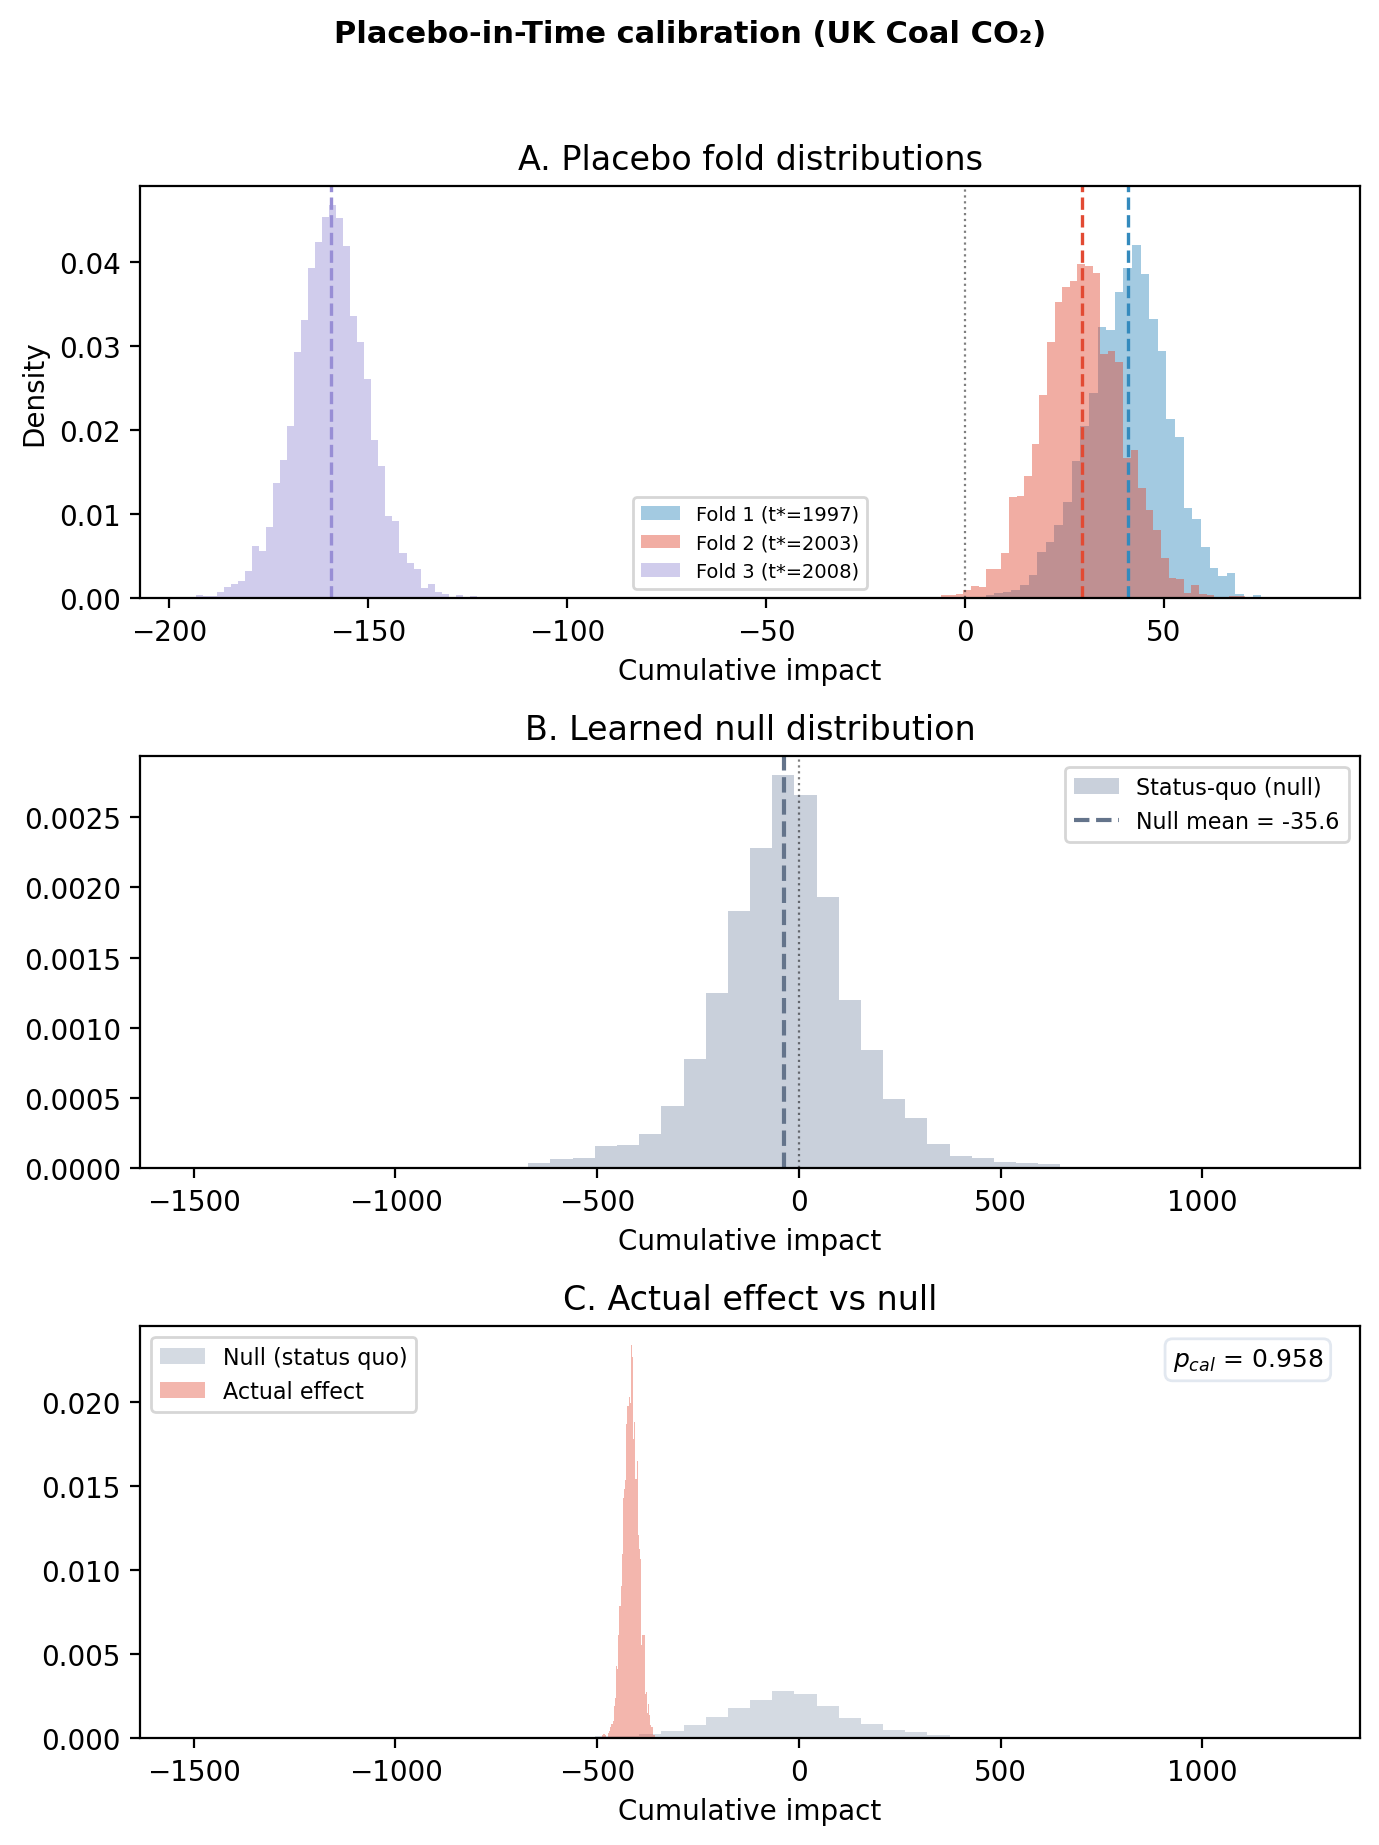

In [10]:
plot_placebo_calibration(
    pit_check=pit_check,
    original_result=result_pit.experiment,
    title="Placebo-in-Time calibration (UK Coal CO₂)",
)

The coal CO₂ effect (red, panel C) sits well to the left of the null mass, and the printed `P(actual outside null) = 0.95` confirms it: the observed cumulative drop is far outside what this model produces in placebo runs where nothing happened. With $p_{\text{cal}} \ge 0.95$, the placebo check returns `SUPPORTED` for coal CO₂.

But even a well-calibrated thermometer can still be pointed at the wrong thing. The next question is whether the *mechanism* is consistent: if coal really died, where did the energy go?

## Question 3: Falsification --- where did the energy go?

### The detective's logic

Gallea (2026) tells a fascinating story about Walker Hanlon, who studied the effect of London fog on mortality. Death rates spiked during fog weeks.  His hypothesis: fog traps pollution, increasing respiratory disease.  But a good detective asks: could the deaths be from traffic accidents (poor visibility)?  Or crime (fog as cover)? Pneumonia spiked. Accidents and crime didn't. Only the outcome that *should* respond to pollution actually did.

**We apply the same logic**. The Carbon Price Floor taxes carbon from electricity generation. If it works, the energy system should reorganise: coal dies, but energy demand doesn't vanish. The electrons have to come from somewhere. The most likely substitute in 2013 was **natural gas**, cheaper than coal once the carbon floor bit, and already available at scale.

If gas CO₂ *rose* after 2013, that is evidence of substitution. It means the policy didn't reduce energy production; it redirected it. And that makes the coal CO₂ decline much harder to attribute to a recession or data artefact.

### Did gas CO₂ rise?

To answer this we reuse exactly the pipeline we applied to coal: an ITS fit on `gas_co2`, wrapped in a `PlaceboInTime` sensitivity check with the same `n_folds=3`, random selection, and `min_gap=2`. Only the target series changes. If fuel substitution really happened, we expect a clear positive break --- the actual cumulative effect should sit *above* the placebo null distribution that the model reports for the pre-period.

In [11]:
result_pit_gas = cp.Pipeline(
    data=df_uk[["gas_co2"]],
    steps=[
        cp.EstimateEffect(
            method=cp.InterruptedTimeSeries,
            treatment_time=treatment_time,
            formula="gas_co2 ~ 1",
            model=its_model(),
        ),
        cp.SensitivityAnalysis(
            checks=[
                cp.checks.PlaceboInTime(
                    n_folds=3, selection_method="random", min_gap=2
                ),
            ]
        ),
    ],
).run()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (8 chains in 8 jobs)
NUTS: [fourier_beta, delta, beta, sigma]


Output()

Sampling 8 chains for 1_000 tune and 500 draw iterations (8_000 + 4_000 draws total) took 16 seconds.
Sampling: [beta, delta, fourier_beta, sigma, y_hat]
Sampling: [y_hat]


Output()

Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (8 chains in 8 jobs)
NUTS: [fourier_beta, delta, beta, sigma]


...

Output()

Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_status_quo, tau_status_quo, fold_z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
Sampling: [theta_new]


Output()

In [12]:
pit_check_gas = result_pit_gas.sensitivity_results[0]
print(pit_check_gas.text)

Placebo-in-time analysis: 3 of 3 folds completed.
Hierarchical status-quo model: mu=-77.16, tau=178.44.
Actual cumulative impact: 192.33. P(actual outside null) = 0.659.
NOT SUPPORTED — actual effect is within the null distribution.
Fold 1: pseudo treatment at 1997-01-01 00:00:00 — mean=-209.65, sd=16.14
Fold 2: pseudo treatment at 2002-01-01 00:00:00 — mean=-71.85, sd=13.03
Fold 3: pseudo treatment at 2007-01-01 00:00:00 — mean=65.46, sd=10.53


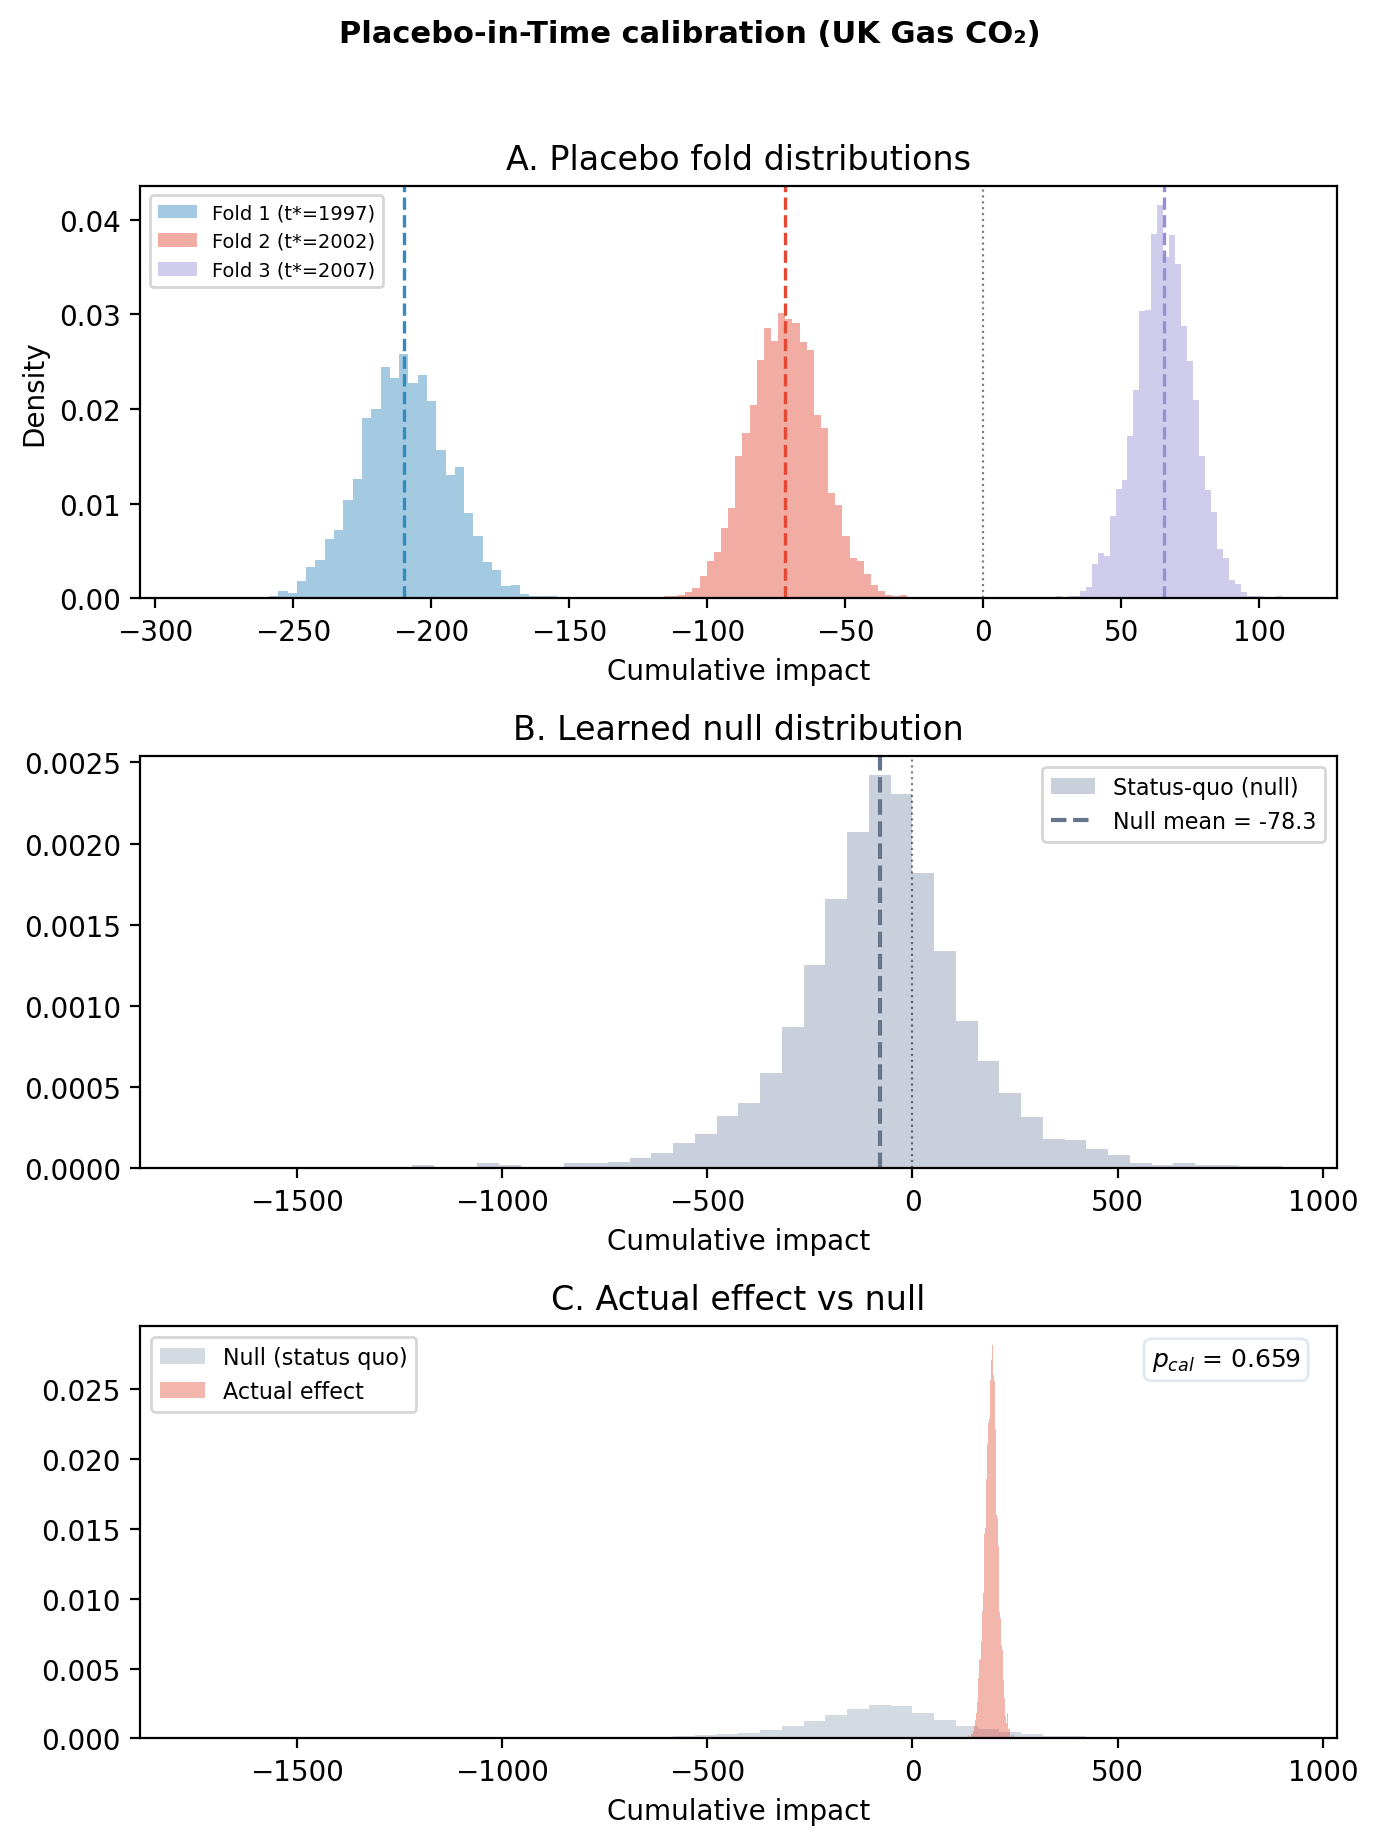

In [13]:
plot_placebo_calibration(
    pit_check=pit_check_gas,
    original_result=result_pit_gas.experiment,
    title="Placebo-in-Time calibration (UK Gas CO₂)",
)

As we thought, looks like the energy system didn't shrink, it *reorganised*.  Coal's share was absorbed by gas-fired generation, exactly as the policy intended. This is the substitution channel in action.

## Question 4: Did total CO₂ or energy demand change?

But notice the implication: if coal CO₂ went down and gas CO₂ went up, the net effect on *total* CO₂ may be smaller than either component alone.  The policy didn't eliminate emissions; it shifted them toward a less carbon-intensive fuel. That is the boundary check our table promised: if total CO₂ or energy demand also moved in suspicious ways, the coal story would need a more careful retelling.

### Did total CO₂ change?

If the CPF mostly reshuffled emissions from coal to gas, total CO₂ might show a more modest break, or none at all. This would not mean the policy failed; it would mean its *first-order* effect was fuel switching.

In [14]:
result_pit_co2 = cp.Pipeline(
    data=df_uk[["co2"]],
    steps=[
        cp.EstimateEffect(
            method=cp.InterruptedTimeSeries,
            treatment_time=treatment_time,
            formula="co2 ~ 1",
            model=its_model(),
        ),
        cp.SensitivityAnalysis(
            checks=[
                cp.checks.PlaceboInTime(
                    n_folds=3, selection_method="random", min_gap=2
                ),
            ]
        ),
    ],
).run()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (8 chains in 8 jobs)
NUTS: [fourier_beta, delta, beta, sigma]


Output()

Sampling 8 chains for 1_000 tune and 500 draw iterations (8_000 + 4_000 draws total) took 240 seconds.
Sampling: [beta, delta, fourier_beta, sigma, y_hat]
Sampling: [y_hat]


Output()

Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (8 chains in 8 jobs)
NUTS: [fourier_beta, delta, beta, sigma]


...

Output()

Sampling: [y_hat]
Sampling: [y_hat]
Sampling: [y_hat]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_status_quo, tau_status_quo, fold_z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
Sampling: [theta_new]


Output()

In [15]:
pit_check_co2 = result_pit_co2.sensitivity_results[0]
print(pit_check_co2.text)

Placebo-in-time analysis: 3 of 3 folds completed.
Hierarchical status-quo model: mu=-222.23, tau=299.87.
Actual cumulative impact: -45.05. P(actual outside null) = 0.084.
NOT SUPPORTED — actual effect is within the null distribution.
Fold 1: pseudo treatment at 1997-01-01 00:00:00 — mean=-409.09, sd=19.14
Fold 2: pseudo treatment at 2003-01-01 00:00:00 — mean=18.96, sd=11.97
Fold 3: pseudo treatment at 2008-01-01 00:00:00 — mean=-262.31, sd=14.61


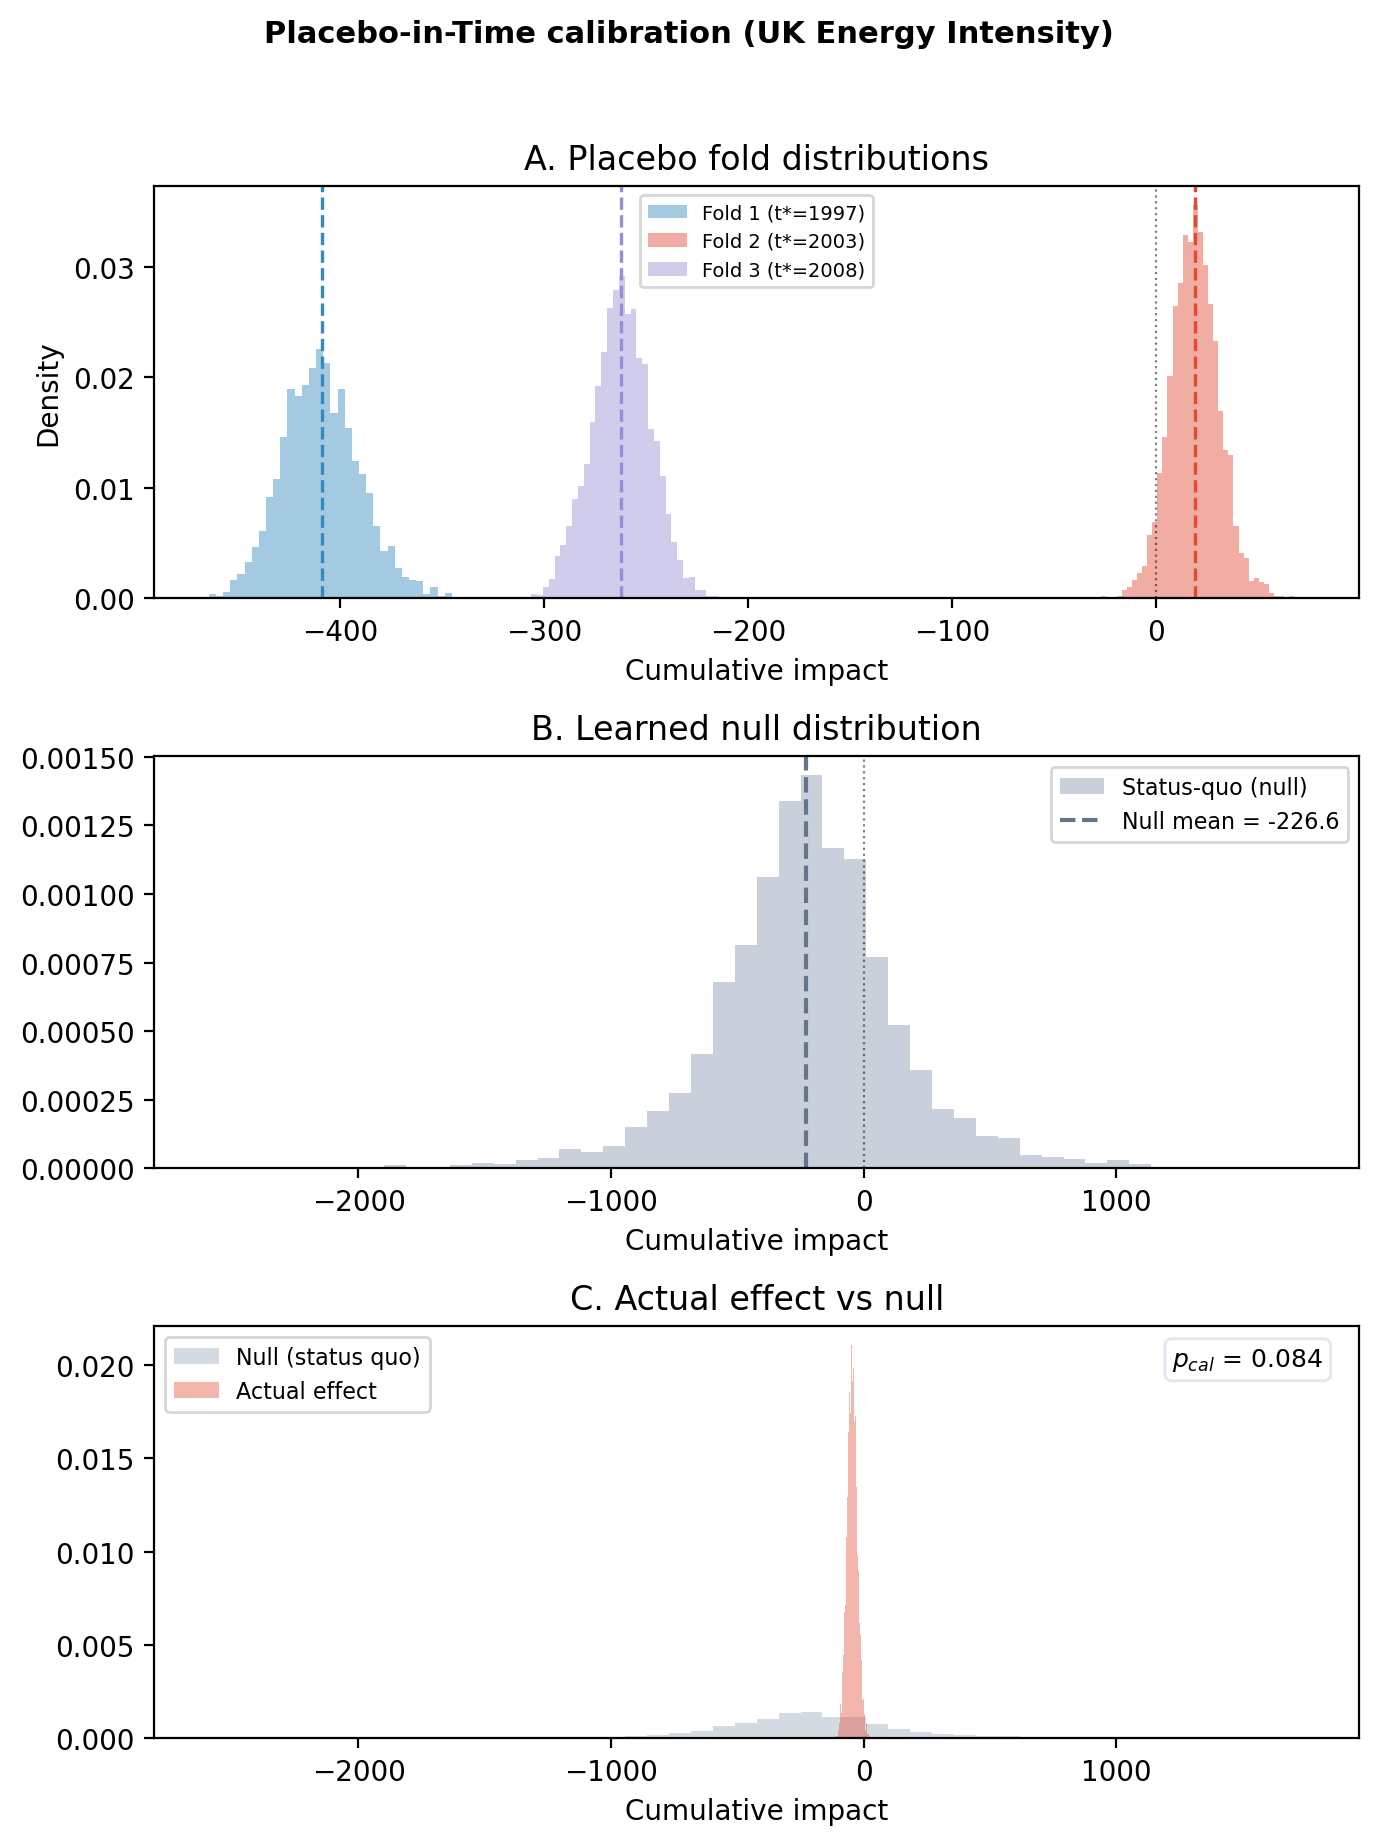

In [16]:
plot_placebo_calibration(
    pit_check=pit_check_co2,
    original_result=result_pit_co2.experiment,
    title="Placebo-in-Time calibration (UK Energy Intensity)",
)

This is exactly what we predicted. The effect on total CO₂ is weaker, and even when it's below zero the change it's perfectly capture by the "usual" mistakes of the model. This support our hypothesis around the redistribution from coal to gas partly cancels out. This is not a failure of the policy; it is consistent with the mechanism. The CPF killed coal, gas absorbed the slack, with other more sustainable sources and the net carbon reduction was smaller than the coal-specific one.

This result also *strengthens* our causal claim about coal. If the coal CO₂ drop were driven by a data error or a recession, we would see the same drop in total CO₂. The fact that total CO₂ shows a smaller break supports the substitution story.

### Did energy demand change?

The final check. A skeptic's strongest objection: "Maybe the UK economy crashed in 2013, and the drop in CO₂ was just a byproduct of a recession."

If that were true, the relationship between energy use and economic output would break. We can test this by looking at Energy Intensity (energy_per_gdp) — how much energy it takes to generate one dollar of GDP.

The Carbon Price Floor was designed to clean up the supply side (taxing dirty fuel), not to destroy the demand side (economic output). If the policy worked as intended, the UK economy should have continued generating wealth at its historical rate of energy efficiency. If the `energy_per_gdp` trend remains perfectly stable through 2013, the recession story collapses.

:::{note}
We switch to a different model here, `StateSpaceTimeSeries`, to demonstrate that CausalPy's sensitivity framework works with any *estimator* --- here "estimator" means the underlying counterfactual model (`BayesianBasisExpansionTimeSeries`, `StateSpaceTimeSeries`, ...), still inside the ITS quasi-experimental approach. The identifying assumptions of ITS itself, and any model-specific assumptions, still need to hold; the PlaceboInTime machinery is just agnostic to which counterfactual model you plug in.
:::

In [17]:
sampler_kwargs = {
    "nuts_sampler": "nutpie",
    "nuts_sampler_kwargs": {"backend": "jax", "gradient_backend": "jax"},
    "target_accept": 0.94,
}


def states_space_model():
    """Fresh StateSpaceTimeSeries model (single-use)."""
    return cp.pymc_models.StateSpaceTimeSeries(
        level_order=3,
        seasonal_length=2,
        sample_kwargs=sampler_kwargs,
        mode="FAST_COMPILE",
    )


# Calculate GDP per capita
df_uk_epc = df_uk.dropna(subset=["energy_per_gdp"]).copy()

result_epc = cp.InterruptedTimeSeries(
    data=df_uk_epc[["energy_per_gdp"]],
    treatment_time=treatment_time,
    formula="energy_per_gdp ~ 1",
    model=states_space_model(),
)

                                Model Requirements                                
                                                                                  
  Variable              Shape    Constraints                          Dimensions  
 ──────────────────────────────────────────────────────────────────────────────── 
  initial_level_trend   (3,)                              ('state_level_trend',)  
  sigma_level_trend     (3,)     Positive                 ('shock_level_trend',)  
  params_freq           (1,)                                     ('state_freq',)  
  sigma_freq            ()       Positive                                   None  
  P0                    (5, 5)   Positive semi-definite   ('state', 'state_aux')  
                                                                                  
   These parameters should be assigned priors inside a PyMC model block before    
                    calling the build_statespace_graph method.                    

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,4,0.34,15
,2000,0,0.34,15
,2000,2,0.36,15
,2000,0,0.37,7


Sampling: [obs]


Output()

Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

Sampling: [forecast_combined]


Output()

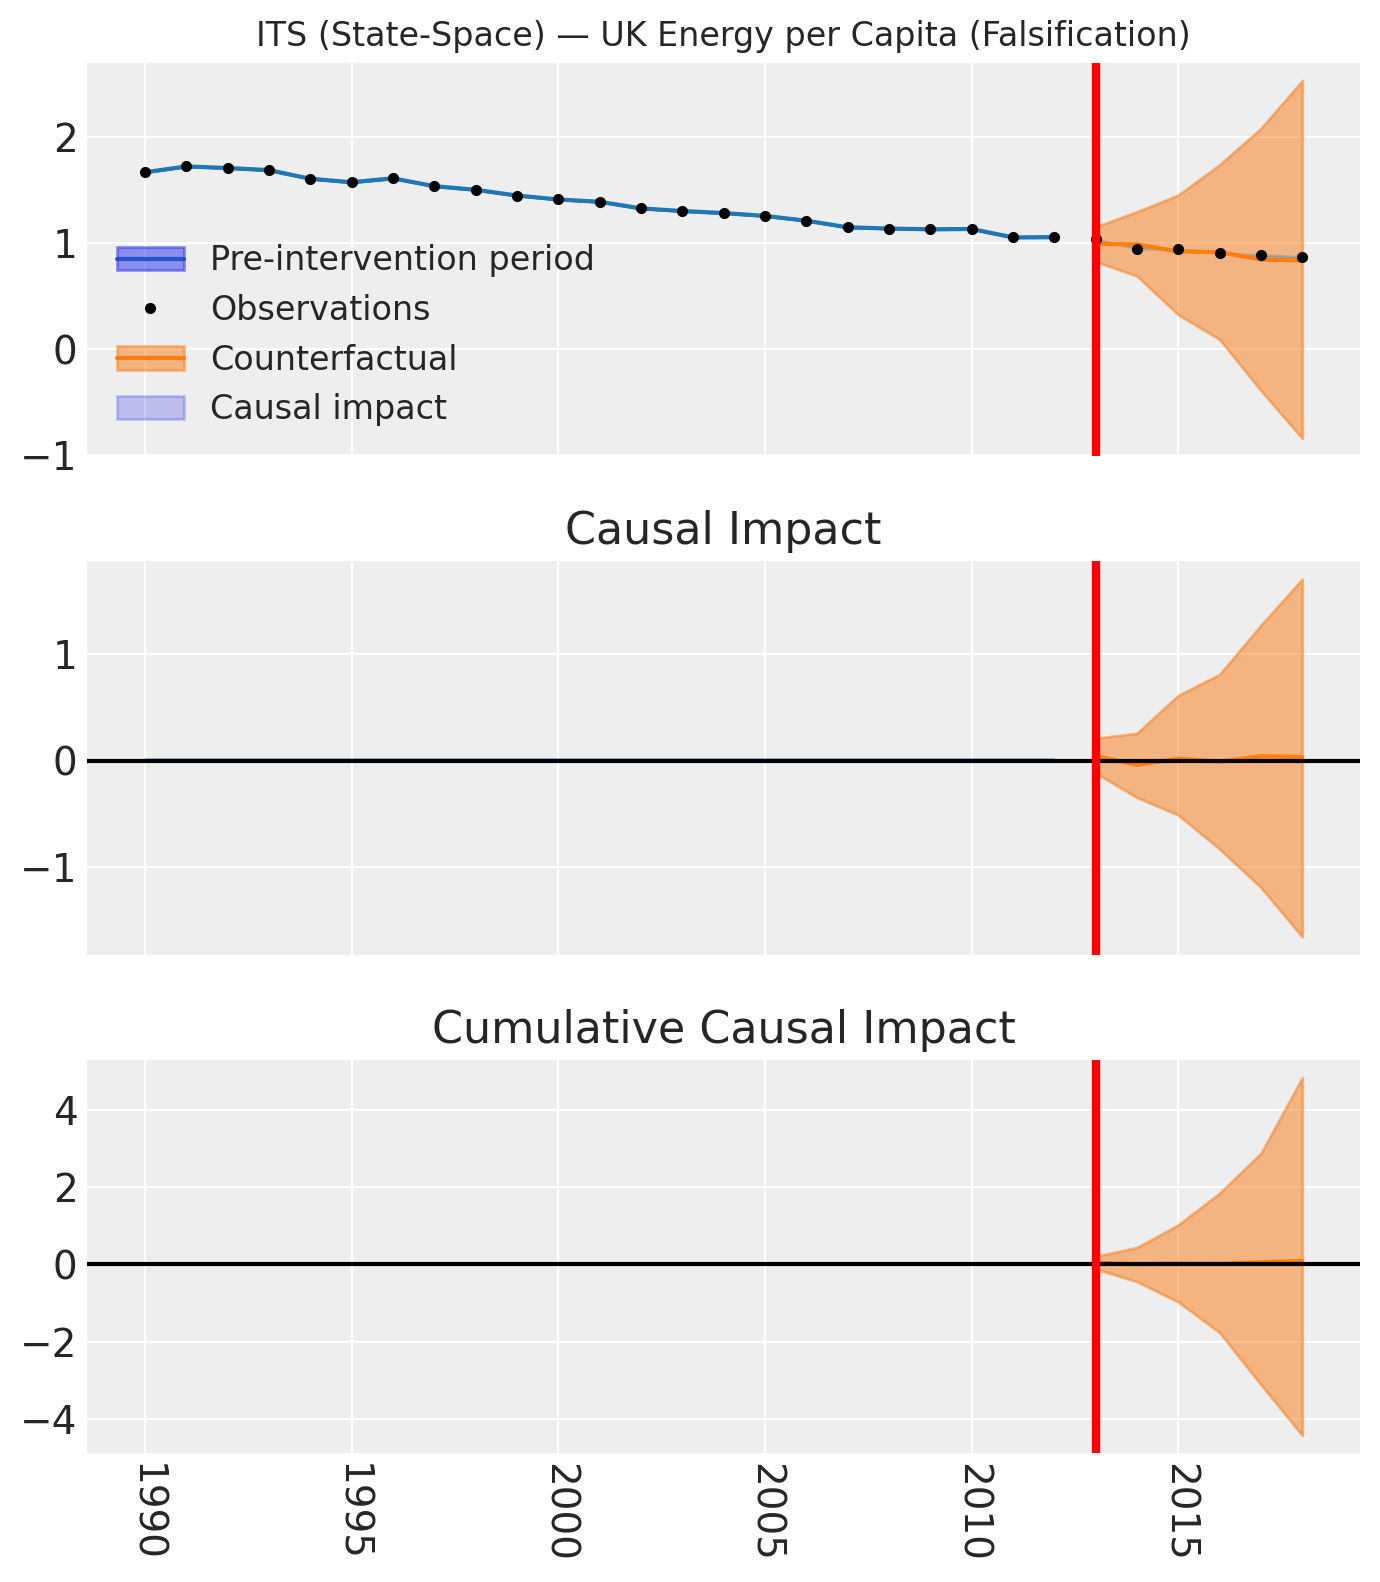

In [18]:
fig, axes = result_epc.plot(show=False)
axes[0].set_title("ITS (State-Space) — UK Energy per Capita (Falsification)")
plt.tight_layout()
plt.show()

Energy per GPD shows no meaningful break at 2013.  The actual trajectory hugs the counterfactual.  People kept using roughly the same
amount of energy --- they just stopped getting it from coal.

## Assembling the case

We did not prove that the Carbon Price Floor caused the decline in coal CO₂. Proof is not available in observational data. What we did is accumulate four pieces of evidence, each small, each pointing in the same direction:

| Step | What we found | What it rules out |
|:-----|:--------------|:------------------|
| **Coal CO₂ collapsed** | Large effect, clearly outside the null | Random fluctuation or model artefact |
| **Gas CO₂ rose** | Substitution toward gas | General decline in all fuels |
| **Total CO₂ effect is weaker** | Consistent with redistribution, not elimination | Data error that would affect all CO₂ equally |
| **Energy demand stayed flat** | Demand unchanged | Recession or demand shock |

No single finding is conclusive. But the four together tell a coherent story: the Carbon Price Floor made coal uncompetitive, energy producers switched to gas, coal CO₂ collapsed, total CO₂ fell modestly, and energy demand was unaffected.

:::{.callout-important}
## The epistemological lesson

A credible interval that excludes zero is necessary but not sufficient. The real question is not "is the effect different from zero?" but "is the effect different from what the model would report even if nothing happened?"  Placebo-in-Time (Bugaev & Trujillo, 2026) gives you a calibrated answer to that second question.

And even a calibrated estimate is not enough on its own. You need to trace the mechanism, check the boundaries, and ask whether the story holds from multiple angles.  Gallea (2026) calls this thinking like a detective.  We call it responsible causal inference.

In ITS settings in particular, placebo-in-time turns the unfalsifiable assumption *'the pre-trend would have continued, undisturbed'* into something you can actually probe with the data you already have: by repeatedly asking the model what it would have claimed if nothing had happened, you build an empirical floor for what counts as evidence. It does not give you certainty, but it makes ITS-based causal claims meaningfully more robust, and easier to defend to a skeptical reader.
:::